O caso abaixo achará o comportamento ótimo da bateria para qualquer cenário


✓ Objetivo total: 9.4217 BRL/dia
  Operacional (custo esperado diário): -11.7772 BRL/dia
  PV_cap (kW): 10.0000 -> custo diário PV: 12.3812 BRL/dia
  BESS_cap (kWh): 7.9402 -> custo diário BESS: 8.8178 BRL/dia
  Daily capacity cost (PV+BESS): 21.1989 BRL/dia

 base (π=0.34)
 Hora  Rede_compra  Rede_venda    PV  Demanda  BESS_carga  BESS_descarga  E_BESS  state
    0         1.93        0.00  0.00     1.93        0.00          -0.00    0.00      0
    1         1.61        0.00  0.00     1.61        0.00          -0.00    0.00      0
    2         1.41        0.00  0.00     1.41        0.00          -0.00    0.00      0
    3         1.33        0.00  0.00     1.33        0.00          -0.00    0.00      0
    4         1.18        0.00  0.20     1.38        0.00          -0.00    0.00      0
    5         0.49        0.00  1.15     1.64        0.00          -0.00    0.00      0
    6         0.00        0.76  2.70     1.94        0.00          -0.00    0.00      0
    7         0.00  

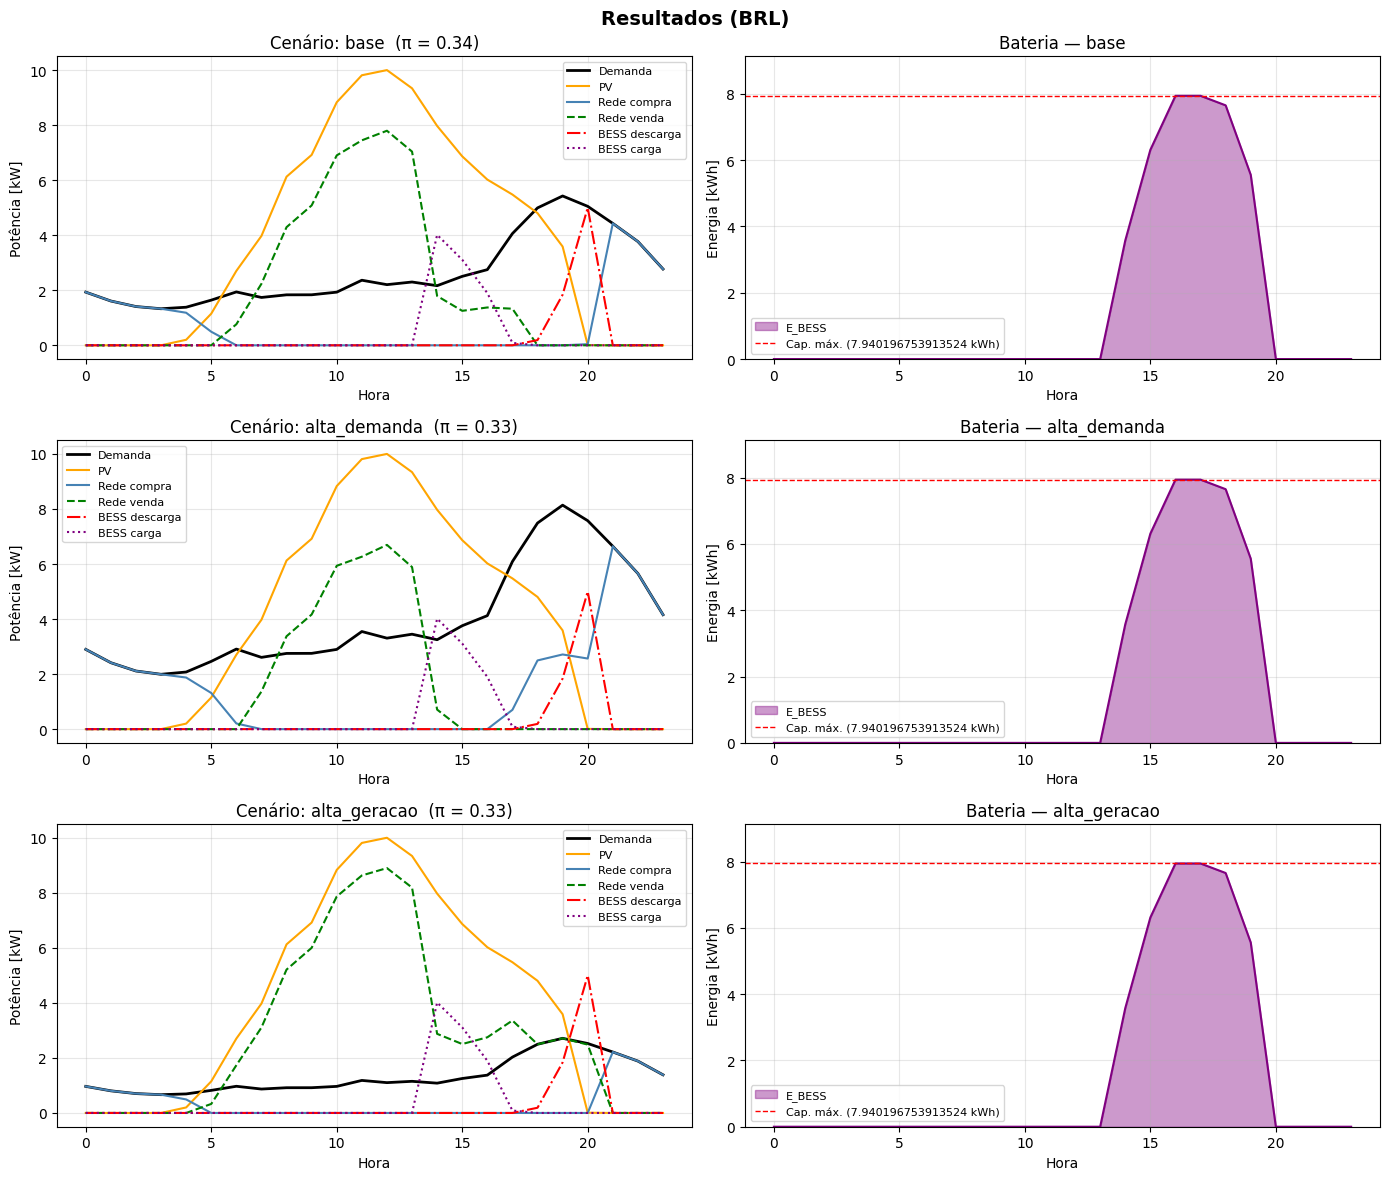


PV otimizada encontrada: 10.0000 kW

Varredura BESS (PV fixo na capacidade ótima) — valores em BRL/dia
   BESS_kWh  Operational_daily_BRL  Daily_capacity_cost_BRL  Total_daily_BRL
0         0              -2.007709                12.381155        10.373447
1         1              -3.385305                13.491676        10.106371
2         2              -4.762108                14.602196         9.840088
3         4              -7.271897                16.823237         9.551341
4         8             -11.833501                21.265319         9.431818
5        12             -15.546650                25.707401        10.160751
6        16             -18.705029                30.149483        11.444454
7        20             -20.750149                34.591564        13.841416


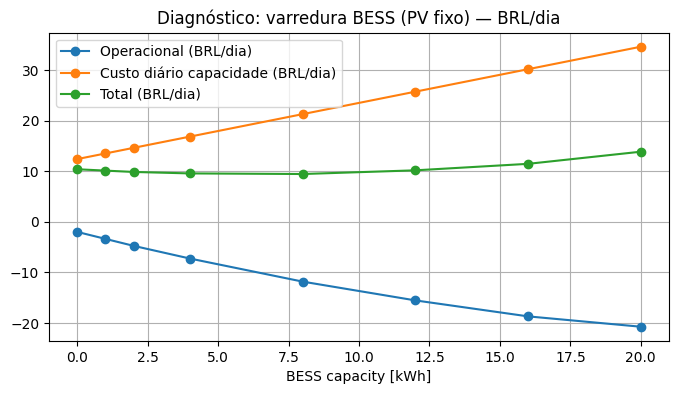

In [ ]:
from pyomo.opt import SolverFactory, SolverStatus, TerminationCondition
import pyomo.environ as pyo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Dados ──────────────────────────────────────────────────────────────────────
P_demand_data = [
    1.9317, 1.6090, 1.4079, 1.3281, 1.3834, 1.6413,
    1.9395, 1.7383, 1.8341, 1.8354, 1.9312, 2.3645,
    2.2038, 2.2997, 2.1659, 2.5046, 2.7490, 4.0597,
    4.9924, 5.4257, 5.0491, 4.4294, 3.7692, 2.7716
]
P_pv_data = [
    0.0000, 0.0000, 0.0000, 0.0000, 0.0796, 0.4565,
    1.0742, 1.5790, 2.4343, 2.7488, 3.5092, 3.8988,
    3.9734, 3.7105, 3.1671, 2.7282, 2.3926, 2.1764,
    1.9083, 1.4257, 0.0034, 0.0000, 0.0000, 0.0000
]
# Fator de conversão USD -> BRL
FX = 4.96

tariff_buy = [
    0.22419, 0.22419, 0.22419, 0.22419, 0.22419, 0.22419,
    0.22419, 0.22419, 0.22419, 0.22419, 0.22419, 0.22419,
    0.22419, 0.22419, 0.22419, 0.22419, 0.22419, 0.32629,
    0.51792, 0.51792, 0.51792, 0.32629, 0.22419, 0.22419
]
# converte tarifas para BRL
tariff_buy = [round(x * FX, 6) for x in tariff_buy]

parameters = {
    "Grid": {"Pmax": 90},
    "BESS": {
        "Pmax": 5.0,
        "eff": 0.90,
        "self_discharge": 0.01,
        "capacity": 8,
        "initial capacity": 0,
    }
}
scenarios = {
    "base": {
        "P_demand": P_demand_data,
        "P_pv":     P_pv_data,
        "prob":     0.34,
    },
    "alta_demanda": {
        "P_demand": [round(x * 1.5, 4) for x in P_demand_data],
        "P_pv":     [round(x * 0.5, 4) for x in P_pv_data],
        "prob":     0.33,
    },
    "alta_geracao": {
        "P_demand": [round(x * 0.5, 4) for x in P_demand_data],
        "P_pv":     [round(x * 1.5, 4) for x in P_pv_data],
        "prob":     0.33,
    },
}


class SmartHomeStochastic:
    def __init__(self, parameters, scenarios, tariff_buy):
        # Atributos do objeto — precisam de self para sobreviver entre métodos
        self.parameters = parameters
        self.scenarios  = scenarios
        self.tariff_buy = tariff_buy
        self.results    = {}        # será preenchido em solve()

    def build(self):
        m     = pyo.ConcreteModel('SmartHome_Stochastic')
        delta = 1.0

        CAPEX_PV = 600.0 * FX                # BRL/kW
        OPEX_PV_RATE = 0.05                  # 5% do CAPEX (taxa anual)
        CAPEX_BESS = 800.0 * FX              # BRL/kWh
        OPEX_BESS_PER_KWH = 0.24 * FX        # BRL/kWh (anual, por kWh de capacidade)

        # Anualização do CAPEX (fator de recuperação de capital)
        life_years = 20
        discount_rate = 0.08
        if discount_rate > 0:
            crf = discount_rate * (1 + discount_rate) ** life_years / (((1 + discount_rate) ** life_years) - 1)
        else:
            crf = 1.0 / life_years

        # guardo os parâmetros para diagnóstico em solve()
        self.CAPEX_PV = CAPEX_PV
        self.OPEX_PV_RATE = OPEX_PV_RATE
        self.CAPEX_BESS = CAPEX_BESS
        self.OPEX_BESS_PER_KWH = OPEX_BESS_PER_KWH
        self.crf = crf

        # Conjuntos
        m.T = pyo.RangeSet(0, len(self.tariff_buy) - 1)
        m.S = pyo.Set(initialize=self.scenarios.keys())

        # Parâmetros [matrizes]
        m.P_demand = pyo.Param(m.S, m.T,
                               initialize=lambda m, s, t: self.scenarios[s]['P_demand'][t])
        m.P_pv     = pyo.Param(m.S, m.T,
                               initialize=lambda m, s, t: self.scenarios[s]['P_pv'][t])
        m.prob     = pyo.Param(m.S,
                               initialize=lambda m, s: self.scenarios[s]['prob'])
        m.tariff   = pyo.Param(m.T,
                               initialize=lambda m, t: self.tariff_buy[t])

        # Perfil PV normalizado por cenário (0..1)
        def pv_profile_init(m, s, t):
            pv_list = self.scenarios[s]['P_pv']
            peak = max(pv_list) if max(pv_list) > 0 else 1.0
            return pv_list[t] / peak
        m.PV_profile = pyo.Param(m.S, m.T, initialize=pv_profile_init)

        # Parâmetros BESS
        Pmax_bess = self.parameters['BESS']['Pmax']
        eff       = self.parameters['BESS']['eff']
        beta      = self.parameters['BESS']['self_discharge']
        init_cap  = self.parameters['BESS']['initial capacity']
        Pmax_grid = self.parameters['Grid']['Pmax']

        # Limites realistas
        PV_cap_upper = 10.0    # kW máxima permitida (ajustável)
        BESS_cap_upper = 20.0  # kWh máxima permitida (ajustável)
        max_charge_rate = 1.0  # C-rate

        # Variáveis decisão de capacidade (1ª etapa)
        m.PV_cap = pyo.Var(within=pyo.NonNegativeReals, bounds=(0, PV_cap_upper))
        m.BESS_capacity = pyo.Var(within=pyo.NonNegativeReals, bounds=(0, BESS_cap_upper))

        # Binárias para operação (1ª etapa, mesma para todos os cenários)
        m.state = pyo.Var(m.T, within=pyo.Binary)

        # Variáveis operacionais (2ª etapa)
        m.Pgrid_buy       = pyo.Var(m.S, m.T, within=pyo.NonNegativeReals, bounds=(0, Pmax_grid))
        m.Pgrid_sell      = pyo.Var(m.S, m.T, within=pyo.NonNegativeReals, bounds=(0, Pmax_grid))
        m.Pgrid           = pyo.Var(m.S, m.T, within=pyo.Reals,            bounds=(-Pmax_grid, Pmax_grid))

        m.Pbess_charge    = pyo.Var(m.T, within=pyo.NonNegativeReals, bounds=(0, Pmax_bess))
        m.Pbess_discharge = pyo.Var(m.T, within=pyo.NonNegativeReals, bounds=(0, Pmax_bess))
        m.E_bess          = pyo.Var(m.T, within=pyo.NonNegativeReals, bounds=(0, BESS_cap_upper))

        # Variável auxiliar para linearizar BESS_capacity * state[t]
        m.BESS_cap_on = pyo.Var(m.T, within=pyo.NonNegativeReals, bounds=(0, BESS_cap_upper))

        # Limita energia armazenada pela capacidade decisão
        def bess_capacity_limit(m, t):
            return m.E_bess[t] <= m.BESS_capacity
        m.bess_cap_limit = pyo.Constraint(m.T, rule=bess_capacity_limit)

        # Linearização: BESS_cap_on approximates BESS_capacity * state[t]
        def cap_on_ub1(m, t):
            return m.BESS_cap_on[t] <= m.BESS_capacity
        m.cap_on_ub1 = pyo.Constraint(m.T, rule=cap_on_ub1)

        def cap_on_ub2(m, t):
            return m.BESS_cap_on[t] <= BESS_cap_upper * m.state[t]
        m.cap_on_ub2 = pyo.Constraint(m.T, rule=cap_on_ub2)

        def cap_on_lb(m, t):
            return m.BESS_cap_on[t] >= m.BESS_capacity - BESS_cap_upper * (1 - m.state[t])
        m.cap_on_lb = pyo.Constraint(m.T, rule=cap_on_lb)

        # Limita potência de descarga/carga pela capacidade (C-rate)
        def bess_discharge_limit(m, s, t):
            return m.Pbess_discharge[t] <= max_charge_rate * m.BESS_cap_on[t]
        m.dis_limit = pyo.Constraint(m.S, m.T, rule=bess_discharge_limit)

        def bess_charge_limit(m, s, t):
            return m.Pbess_charge[t] <= max_charge_rate * (m.BESS_capacity - m.BESS_cap_on[t])
        m.ch_limit = pyo.Constraint(m.S, m.T, rule=bess_charge_limit)

        # Restrições ──────────────────────────────────────────────────────────────────────
        def power_balance_rule(m, s, t):
            return (+ m.Pgrid[s, t]
                    + m.PV_profile[s, t] * m.PV_cap
                    + m.Pbess_discharge[t]
                    ==
                    + m.P_demand[s, t]
                    + m.Pbess_charge[t])
        m.power_balance = pyo.Constraint(m.S, m.T, rule=power_balance_rule)

        def grid_balance_rule(m, s, t):
            return m.Pgrid[s, t] == m.Pgrid_buy[s, t] - m.Pgrid_sell[s, t]
        m.grid_balance = pyo.Constraint(m.S, m.T, rule=grid_balance_rule)

        def bess_energy_rule(m, t):
            charge    = eff * delta * m.Pbess_charge[t]
            discharge = delta * m.Pbess_discharge[t] / eff
            loss      = beta * delta * m.E_bess[t]

            if t == 0:
                E_prev = init_cap
            else:
                E_prev = m.E_bess[t-1]
            return m.E_bess[t] == E_prev + charge - discharge - loss
        m.bess_energy = pyo.Constraint(m.T, rule=bess_energy_rule)

        # Objetivo: custo esperado operacional + custo diário da capacidade (BRL/dia)
        def objective_rule(m):
            operational = delta * sum(
                m.prob[s] * sum(
                    m.tariff[t] * m.Pgrid_buy[s, t] - 0.7 * m.tariff[t] * m.Pgrid_sell[s, t]
                    for t in m.T
                )
                for s in m.S
            )

            annual_capex_pv = CAPEX_PV * crf * m.PV_cap
            annual_opex_pv = OPEX_PV_RATE * CAPEX_PV * m.PV_cap
            annual_capex_bess = CAPEX_BESS * crf * m.BESS_capacity
            annual_opex_bess = OPEX_BESS_PER_KWH * m.BESS_capacity

            daily_capacity_cost = (annual_capex_pv + annual_opex_pv + annual_capex_bess + annual_opex_bess) / 365.0

            return operational + daily_capacity_cost
        m.objective = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

        self.model = m

    def solve(self):
        solver   = SolverFactory('highs')
        solution = solver.solve(self.model)

        m = self.model
        # Recomputo parâmetros locais para diagnóstico
        CAPEX_PV = self.CAPEX_PV
        OPEX_PV_RATE = self.OPEX_PV_RATE
        CAPEX_BESS = self.CAPEX_BESS
        OPEX_BESS_PER_KWH = self.OPEX_BESS_PER_KWH
        crf = self.crf
        delta = 1.0

        if (solution.solver.status == SolverStatus.ok and
                solution.solver.termination_condition == TerminationCondition.optimal):
            # calculo operacional explicitamente
            operational_val = pyo.value(delta * sum(
                m.prob[s] * sum(
                    m.tariff[t] * m.Pgrid_buy[s, t] - 0.7 * m.tariff[t] * m.Pgrid_sell[s, t]
                    for t in m.T
                )
                for s in m.S
            ))

            pv_cap = pyo.value(m.PV_cap)
            bess_cap = pyo.value(m.BESS_capacity)

            annual_capex_pv = CAPEX_PV * crf * pv_cap
            annual_opex_pv = OPEX_PV_RATE * CAPEX_PV * pv_cap
            annual_capex_bess = CAPEX_BESS * crf * bess_cap
            annual_opex_bess = OPEX_BESS_PER_KWH * bess_cap
            daily_capacity_cost = (annual_capex_pv + annual_opex_pv + annual_capex_bess + annual_opex_bess) / 365.0

            print(f"\n✓ Objetivo total: {pyo.value(m.objective):.4f} BRL/dia")
            print(f"  Operacional (custo esperado diário): {operational_val:.4f} BRL/dia")
            print(f"  PV_cap (kW): {pv_cap:.4f} -> custo diário PV: {(annual_capex_pv+annual_opex_pv)/365.0:.4f} BRL/dia")
            print(f"  BESS_cap (kWh): {bess_cap:.4f} -> custo diário BESS: {(annual_capex_bess+annual_opex_bess)/365.0:.4f} BRL/dia")
            print(f"  Daily capacity cost (PV+BESS): {daily_capacity_cost:.4f} BRL/dia")
        else:
            print("✗ Solver não encontrou solução ótima.")
            print(f"  Status: {solution.solver.status}")
            print(f"  Termination: {solution.solver.termination_condition}")
            return

        # Coleta resultados em self.results para o plot usar depois
        for s in m.S:
            rows = []
            for t in m.T:
                rows.append({
                    'Hora':            t,
                    'Rede_compra':     pyo.value(m.Pgrid_buy[s, t]),
                    'Rede_venda':      pyo.value(m.Pgrid_sell[s, t]),
                    'PV':              pyo.value(m.PV_profile[s, t]) * pyo.value(m.PV_cap),
                    'Demanda':         pyo.value(m.P_demand[s, t]),
                    'BESS_carga':      pyo.value(m.Pbess_charge[t]),
                    'BESS_descarga':   pyo.value(m.Pbess_discharge[t]),
                    'E_BESS':          pyo.value(m.E_bess[t]),
                    'state':           int(pyo.value(m.state[t])),
                })

            df = pd.DataFrame(rows)
            print(f"\n {s} (π={self.scenarios[s]['prob']})")
            print(df.round(2).to_string(index=False))
            self.results[s] = df

    def plot(self):
        horas     = list(self.model.T)
        cenarios  = list(self.results.keys())
        n         = len(cenarios)

        fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(14, 4 * n), sharey=False)
        fig.suptitle("Resultados (BRL)", fontsize=14, fontweight='bold')

        for i, s in enumerate(cenarios):
            df  = self.results[s]
            ax1 = axes[i, 0]
            ax2 = axes[i, 1]

            prob = self.scenarios[s]['prob']

            ax1.plot(horas, df['Demanda'],       label='Demanda',      color='black',  linewidth=2)
            ax1.plot(horas, df['PV'],            label='PV',           color='orange', linewidth=1.5)
            ax1.plot(horas, df['Rede_compra'],   label='Rede compra',  color='steelblue', linewidth=1.5)
            ax1.plot(horas, df['Rede_venda'],    label='Rede venda',   color='green',  linewidth=1.5, linestyle='--')
            ax1.plot(horas, df['BESS_descarga'], label='BESS descarga',color='red',    linewidth=1.5, linestyle='-.')
            ax1.plot(horas, df['BESS_carga'],    label='BESS carga',   color='purple', linewidth=1.5, linestyle=':')

            ax1.set_title(f"Cenário: {s}  (π = {prob})")
            ax1.set_ylabel("Potência [kW]")
            ax1.set_xlabel("Hora")
            ax1.legend(fontsize=8)
            ax1.grid(True, alpha=0.3)

            ax2.fill_between(horas, df['E_BESS'], alpha=0.4, color='purple', label='E_BESS')
            ax2.plot(horas, df['E_BESS'], color='purple', linewidth=1.5)

            try:
                cap_max = pyo.value(self.model.BESS_capacity)
            except Exception:
                cap_max = self.parameters['BESS']['capacity']
            ax2.axhline(cap_max, color='red', linestyle='--', linewidth=1, label=f'Cap. máx. ({cap_max} kWh)')

            ax2.set_title(f"Bateria — {s}")
            ax2.set_ylabel("Energia [kWh]")
            ax2.set_xlabel("Hora")
            ax2.set_ylim(0, cap_max * 1.15)
            ax2.legend(fontsize=8)
            ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


# ── Execução ───────────────────────────────────────────────────────────────────
sh = SmartHomeStochastic(parameters, scenarios, tariff_buy)
sh.build()
sh.solve()
sh.plot()

# ── Diagnóstico: varredura de BESS fixas (mantendo PV na capacidade ótima) -- BRL
pv_opt = float(pyo.value(sh.model.PV_cap))
print(f"\nPV otimizada encontrada: {pv_opt:.4f} kW")

bess_list = [0, 1, 2, 4, 8, 12, 16, 20]
rows = []
for b in bess_list:
    sh2 = SmartHomeStochastic(parameters, scenarios, tariff_buy)
    sh2.build()
    m2 = sh2.model
    # fixa capacidades
    m2.PV_cap.fix(pv_opt)
    m2.BESS_capacity.fix(b)

    sol = SolverFactory('highs').solve(m2)
    if (sol.solver.status == SolverStatus.ok and sol.solver.termination_condition == TerminationCondition.optimal):
        operational_val = float(pyo.value(1.0 * sum(
            m2.prob[s] * sum(
                m2.tariff[t] * m2.Pgrid_buy[s, t] - 0.7 * m2.tariff[t] * m2.Pgrid_sell[s, t]
                for t in m2.T
            )
            for s in m2.S
        )))

        annual_capex_pv = sh2.CAPEX_PV * sh2.crf * pv_opt
        annual_opex_pv = sh2.OPEX_PV_RATE * sh2.CAPEX_PV * pv_opt
        annual_capex_bess = sh2.CAPEX_BESS * sh2.crf * b
        annual_opex_bess = sh2.CAPEX_BESS_PER_KWH * b if hasattr(sh2, 'CAPEX_BESS_PER_KWH') else sh2.OPEX_BESS_PER_KWH * b
        # use OPEX_BESS_PER_KWH saved earlier
        annual_opex_bess = sh2.OPEX_BESS_PER_KWH * b
        daily_capacity_cost = (annual_capex_pv + annual_opex_pv + annual_capex_bess + annual_opex_bess) / 365.0

        total = float(pyo.value(m2.objective))
        rows.append({'BESS_kWh': b, 'Operational_daily_BRL': operational_val, 'Daily_capacity_cost_BRL': daily_capacity_cost, 'Total_daily_BRL': total})
    else:
        rows.append({'BESS_kWh': b, 'Operational_daily_BRL': None, 'Daily_capacity_cost_BRL': None, 'Total_daily_BRL': None})

df_sweep = pd.DataFrame(rows)
print('\nVarredura BESS (PV fixo na capacidade ótima) — valores em BRL/dia')
print(df_sweep)

# plota
plt.figure(figsize=(8,4))
plt.plot(df_sweep['BESS_kWh'], df_sweep['Operational_daily_BRL'], marker='o', label='Operacional (BRL/dia)')
plt.plot(df_sweep['BESS_kWh'], df_sweep['Daily_capacity_cost_BRL'], marker='o', label='Custo diário capacidade (BRL/dia)')
plt.plot(df_sweep['BESS_kWh'], df_sweep['Total_daily_BRL'], marker='o', label='Total (BRL/dia)')
plt.xlabel('BESS capacity [kWh]')
plt.grid(True)
plt.legend()
plt.title('Diagnóstico: varredura BESS (PV fixo) — BRL/dia')
plt.show()
